In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.gaussian_process import GaussianProcessRegressor, kernels
from sklearn.gaussian_process.kernels import ConstantKernel, RBF
from scipy.optimize import fmin_cobyla
import numpy as np
import h5py
from sklearn.model_selection import GridSearchCV
from astroML.utils import split_samples
from astroML.utils import completeness_contamination 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve

- `mtot`: the total mass of the binary
- `q`: the mass ratio
- `chi1x`, `chi1y`, `chi1z`, `chi2x`, `chi2y`, `chi2z`: the components of the black-hole spins in a suitable reference frame.
- `ra`, `dec`: the location of the source in the sky
- `iota`: the inclination of the orbital plane'
- `psi`: the polarization angle (gravitational waves have two polarization states much like light)
- `z`: the redshift

In [3]:
data = h5py.File("sample_2e7_design_precessing_higherordermodes_3detectors.h5", 'r')

In [4]:
print("Keys:", list(data.keys()))

Keys: ['chi1x', 'chi1y', 'chi1z', 'chi2x', 'chi2y', 'chi2z', 'dec', 'det', 'iota', 'mtot', 'psi', 'q', 'ra', 'snr', 'z']


In [5]:
det = data["det"] #this determine the detectability of the system

In [6]:
#Keys: ['chi1x', 'chi1y', 'chi1z', 'chi2x', 'chi2y', 'chi2z', 'dec', 'det', 'iota', 'mtot', 'psi', 'q', 'ra', 'snr', 'z']
#this is for the first bh
chi1x = data["chi1x"]
chi1y = data["chi1y"]
chi1z = data["chi1z"]

#this is for the second bh
chi2x = data["chi2x"]
chi2y = data["chi2y"]
chi2z = data["chi2z"]

#ra, dec coordinate in the sky 
ra = data["ra"]
dec = data["dec"]

iota = data["iota"]
mtot = data["mtot"]
psi = data["psi"]
q = data["q"]
snr = data["snr"] 
z = data["z"]

print(len(z))

20000000


In [7]:

X = np.column_stack([chi1x[::100], chi1y[::100], chi1z[::100],
                    chi2x[::100], chi2y[::100], chi2z[::100],
                    ra[::100], dec[::100], iota[::100],
                    mtot[::100], psi[::100], q[::100], z[::100]])

Y = det[::100]

In [8]:
(X_train, X_test), (y_train, y_test) = split_samples(X, Y, [0.75, 0.25], random_state=0) 

In [9]:
print(len(X_train))
print(len(y_train))

150000
150000


[0 0 0 ... 0 0 0]
[1.39526977e-01 5.90529272e-07 6.06606541e-04 ... 5.67776790e-04
 2.73534068e-08 1.69690134e-03]


C:\Users\User\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\User\AppData\Local\Temp\ipykernel_9156\3930641413.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


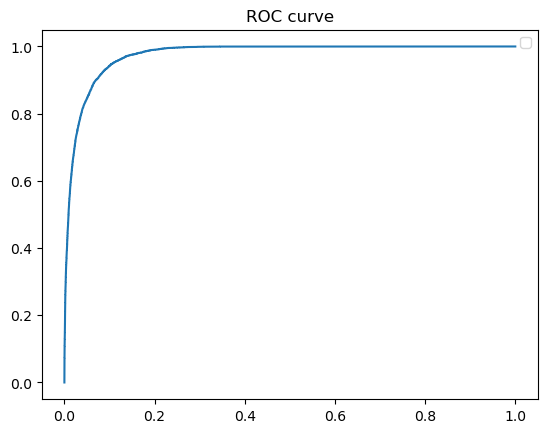

In [10]:
clf = LogisticRegression(class_weight = "balanced")
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test) [:,1] 
print(y_pred)
print(y_prob)

fpr, tpr, thresh = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr)
plt.title("ROC curve")
plt.legend()

In [11]:
completeness, contamination = completeness_contamination(y_pred, y_test)
print(completeness)
print(contamination)

0.9454966616705274
0.3869599787967135


completeness [array(0.14652265), array(0.14805516), array(0.16316718), array(0.14572523), array(0.14853919), array(0.15024266), array(0.14967099), array(0.), array(0.14694534), array(0.154247), array(0.14476642), array(0.1637668), array(0.58714261)]
contamination [array(0.5027933), array(0.49380025), array(0.49598038), array(0.50252078), array(0.49775174), array(0.50224826), array(0.48862243), array(1.), array(0.50183949), array(0.47567789), array(0.50851615), array(0.45878185), array(0.06540401)]


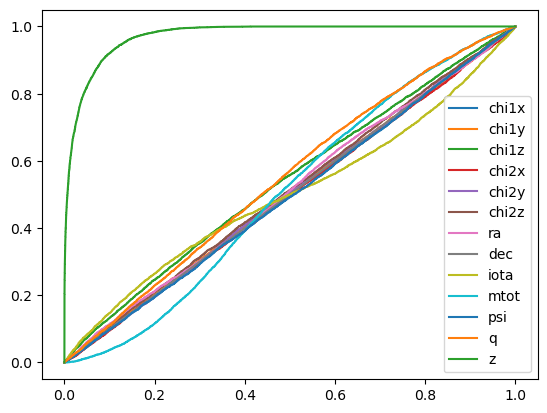

In [16]:
#define completness and contamination 
list_completeness = []
list_contamination = []
lab = ['chi1x', 'chi1y', 'chi1z', 'chi2x', 'chi2y', 'chi2z', 'ra', 'dec', 'iota', 'mtot', 'psi', 'q', 'z']

X = np.column_stack([chi1x[::100], chi1y[::100], chi1z[::100],
                    chi2x[::100], chi2y[::100], chi2z[::100],
                    ra[::100], dec[::100], iota[::100],
                    mtot[::100], psi[::100], q[::100], z[::100]])

Y = det[::100]

for n,l in zip(range(X.shape[1]),lab):
    X_column = X[:,n]
    (X_train, X_test), (y_train, y_test) = split_samples(X_column, Y, [0.75, 0.25], random_state=0) 
    clf = LogisticRegression(class_weight='balanced')
    clf.fit(X_train.reshape(-1, 1), y_train)
    y_pred = clf.predict(X_test.reshape(-1, 1))
    y_prob = clf.predict_proba(X_test.reshape(-1, 1)) [:,1]
    fpr, tpr, thresh = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=l)
    
    comp, cont = completeness_contamination(y_test, y_pred)
    list_completeness.append(comp)
    list_contamination.append(cont)

plt.legend()

print("completeness", list_completeness)
print("contamination", list_contamination)

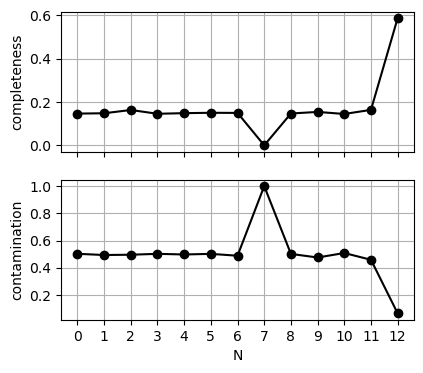

In [40]:
# plot completeness 
fig = plt.figure(figsize=(10, 4))
ax = fig.add_subplot(222)
N = [0,1,2,3,4,5,6,7,8,9,10,11,12]
completeness_flat = np.array(list_completeness).flatten()
contamination_flat = np.array(list_contamination).flatten()

ax.plot(N, completeness_flat, 'o-k', ms=6)

ax.xaxis.set_major_locator(plt.MultipleLocator(1))
ax.yaxis.set_major_locator(plt.MultipleLocator(0.2))
ax.xaxis.set_major_formatter(plt.NullFormatter())

ax.set_ylabel('completeness')
ax.grid(True)

# plot contamination
ax = fig.add_subplot(224)
ax.plot(N, contamination_flat, 'o-k', ms=6)
ax.xaxis.set_major_locator(plt.MultipleLocator(1))
ax.yaxis.set_major_locator(plt.MultipleLocator(0.2))
ax.xaxis.set_major_formatter(plt.FormatStrFormatter('%i'))

ax.set_xlabel('N')
ax.set_ylabel('contamination')
ax.grid(True)

plt.show()